In [ ]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D,MaxPooling2D,AveragePooling2D,Flatten,Dense,Dropout,GlobalAveragePooling2D,Input,concatenate,Resizing
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import seaborn as sns

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

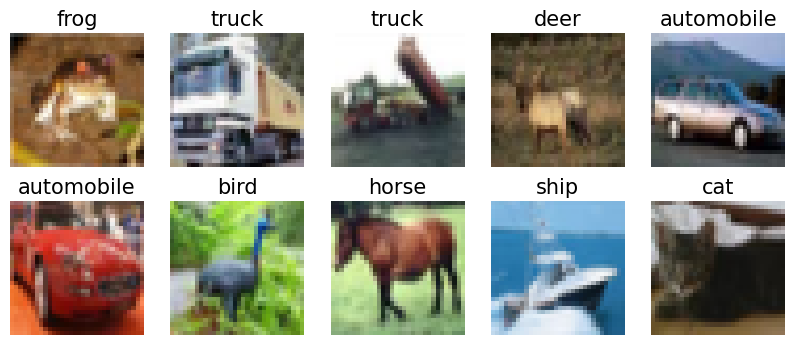

In [57]:
(x_train_raw,y_train_raw),(x_test_raw,y_test_raw)=tf.keras.datasets.cifar10.load_data()
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
plt.figure(figsize=(10,4))
for i in range(10):
 plt.subplot(2,5,i+1)
 plt.imshow(x_train_raw[i])
 plt.title(classes[int(y_train_raw[i][0])])
 plt.axis("off")
plt.savefig("images/sample_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [30]:
x_train=x_train_raw.astype("float32")/255.0
x_test=x_test_raw.astype("float32")/255.0

x_train_main=x_train[:45000]
x_val=x_train[45000:]
y_train_main=y_train_raw[:45000].flatten()
y_val=y_train_raw[45000:].flatten()
y_test=y_test_raw.flatten()

y_train_cat=to_categorical(y_train_main,num_classes=10)
y_val_cat=to_categorical(y_val,num_classes=10)
y_test_cat=to_categorical(y_test,num_classes=10)

print("Training Images:",x_train_main.shape)
print("Validation Images:",x_val.shape)
print("Testing Images:",x_test.shape)
print("Number of Classes:",10)
print("Image Size:",x_train.shape[1:])
print("Normalization:Pixel values scaled to [0,1]")
print("Batch Size:",32)

Training Images: (45000, 32, 32, 3)
Validation Images: (5000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)
Number of Classes: 10
Image Size: (32, 32, 3)
Normalization:Pixel values scaled to [0,1]
Batch Size: 32


In [31]:
input_shape=(32,32,3)

base_model=VGG16(weights="imagenet",include_top=False,input_shape=input_shape)

for layer in base_model.layers:
 layer.trainable=False

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu")(x)
output=Dense(10,activation="softmax")(x)

model=Model(inputs=base_model.input,outputs=output)

total_parameters=model.count_params()
trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

print("Total Parameters:",total_parameters)
print("Trainable Parameters:",trainable_parameters)
print("Non Trainable Parameters:",non_trainable_parameters)

model.compile(optimizer=Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total Parameters: 14848586
Trainable Parameters: 133898
Non Trainable Parameters: 14714688


In [32]:
start_time=time.time()

history=model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

initial_training_time=time.time()-start_time

print("Initial Training Time:",initial_training_time)
print("Final Training Accuracy:",history.history["accuracy"][-1])
print("Final Validation Accuracy:",history.history["val_accuracy"][-1])

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5271 - loss: 1.3577 - val_accuracy: 0.5694 - val_loss: 1.2378
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5890 - loss: 1.1762 - val_accuracy: 0.5866 - val_loss: 1.1856
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6141 - loss: 1.1095 - val_accuracy: 0.6012 - val_loss: 1.1563
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6326 - loss: 1.0578 - val_accuracy: 0.6102 - val_loss: 1.1362
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6481 - loss: 1.0143 - val_accuracy: 0.6144 - val_loss: 1.1234
Initial Training Time: 73.14656233787537
Final Training Accuracy: 0.64811110496521
Final Validation Accuracy: 0.6144000291824341


In [33]:
for layer in base_model.layers:
 if layer.name.startswith("block5"):
  layer.trainable=True
 else:
  layer.trainable=False

fine_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
fine_non_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

fine_history=model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

fine_tuning_time=time.time()-start_time

print("Fine Tuning Time:",fine_tuning_time)
print("Fine Tuned Training Accuracy:",fine_history.history["accuracy"][-1])
print("Fine Tuned Validation Accuracy:",fine_history.history["val_accuracy"][-1])
print("Fine Tuned Trainable Parameters:",fine_trainable_parameters)
print("Fine Tuned Non Trainable Parameters:",fine_non_trainable_parameters)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.6491 - loss: 1.0085 - val_accuracy: 0.7024 - val_loss: 0.8605
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7416 - loss: 0.7306 - val_accuracy: 0.7204 - val_loss: 0.8089
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8059 - loss: 0.5467 - val_accuracy: 0.7066 - val_loss: 0.9502
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8533 - loss: 0.4100 - val_accuracy: 0.6894 - val_loss: 1.0771
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8883 - loss: 0.3193 - val_accuracy: 0.6960 - val_loss: 1.2164
Fine Tuning Time: 97.25957703590393
Fine Tuned Training Accuracy: 0.8882666826248169
Fine Tuned Validation Accuracy: 0.6959999799728394
Fine Tuned Trainable Parameters: 7213322
Fine Tuned Non Trainable Parameters: 7635264


In [34]:
train_acc=history.history["accuracy"]+fine_history.history["accuracy"]
val_acc=history.history["val_accuracy"]+fine_history.history["val_accuracy"]
train_loss=history.history["loss"]+fine_history.history["loss"]
val_loss=history.history["val_loss"]+fine_history.history["val_loss"]

epochs_range=range(1,len(train_acc)+1)
finetune_start=len(history.history["accuracy"])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


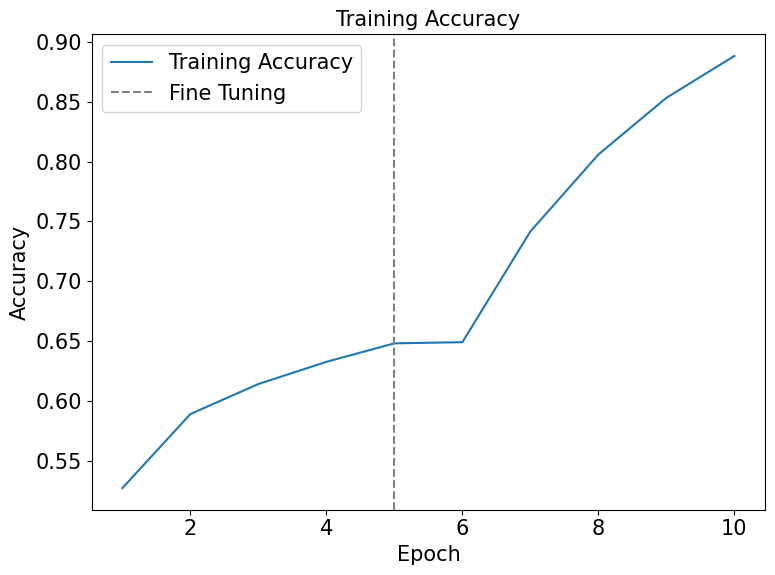

In [49]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,train_acc,label="Training Accuracy")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("images/training_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


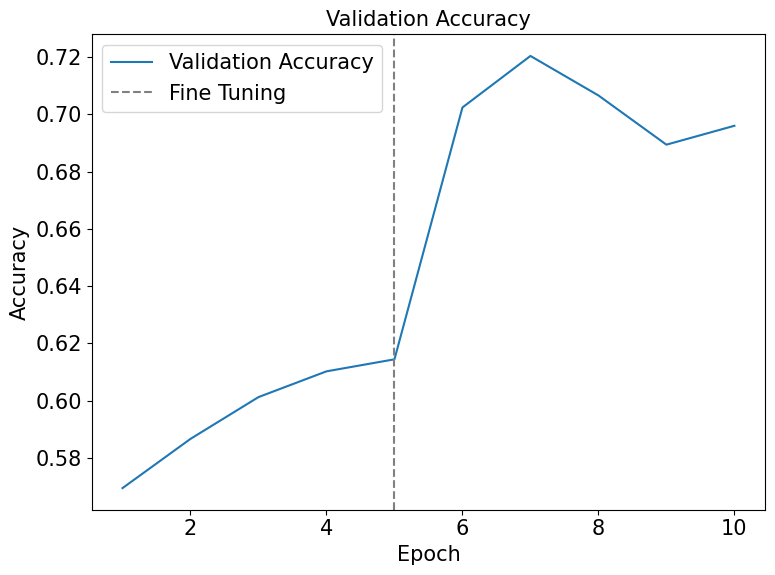

In [50]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,val_acc,label="Validation Accuracy")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("images/validation_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


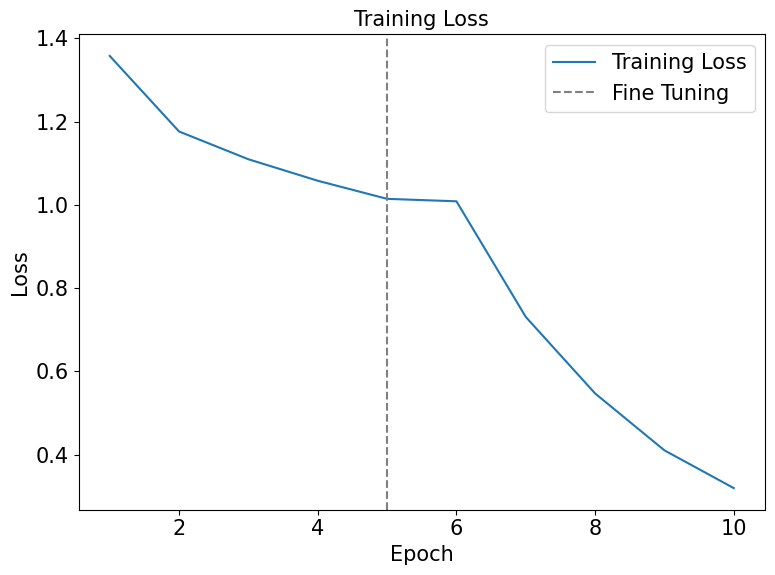

In [51]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,train_loss,label="Training Loss")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/training_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


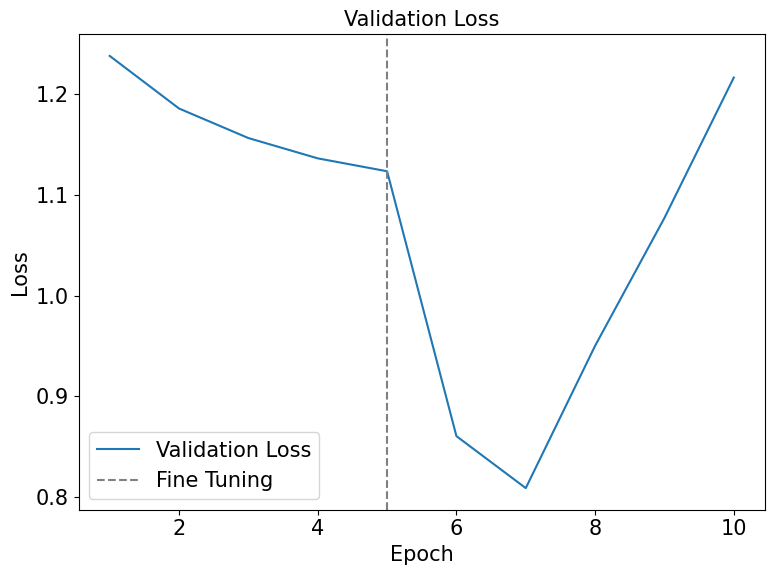

In [52]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,val_loss,label="Validation Loss")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/validation_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [39]:
test_start=time.time()

test_loss,test_accuracy=model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

test_time=time.time()-test_start

y_pred_prob=model.predict(x_test,batch_size=32,verbose=0)
y_pred=np.argmax(y_pred_prob,axis=1)

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average="weighted")
recall=recall_score(y_test,y_pred,average="weighted")
f1=f1_score(y_test,y_pred,average="weighted")

print("Test Loss:",test_loss)
print("Test Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("Test Evaluation Time:",test_time)

Test Loss: 1.2687395811080933
Test Accuracy: 0.687
Precision: 0.7098883103648855
Recall: 0.687
F1-score: 0.6817452064560451
Test Evaluation Time: 3.6858463287353516


In [40]:
initial_val_accuracy=max(history.history["val_accuracy"])
finetuned_val_accuracy=max(fine_history.history["val_accuracy"])

print("Best Validation Accuracy Before Fine Tuning:",initial_val_accuracy*100)
print("Best Validation Accuracy After Fine Tuning:",finetuned_val_accuracy*100)
print("Improvement:",(finetuned_val_accuracy-initial_val_accuracy)*100)

Best Validation Accuracy Before Fine Tuning: 61.44000291824341
Best Validation Accuracy After Fine Tuning: 72.03999757766724
Improvement: 10.599994659423828


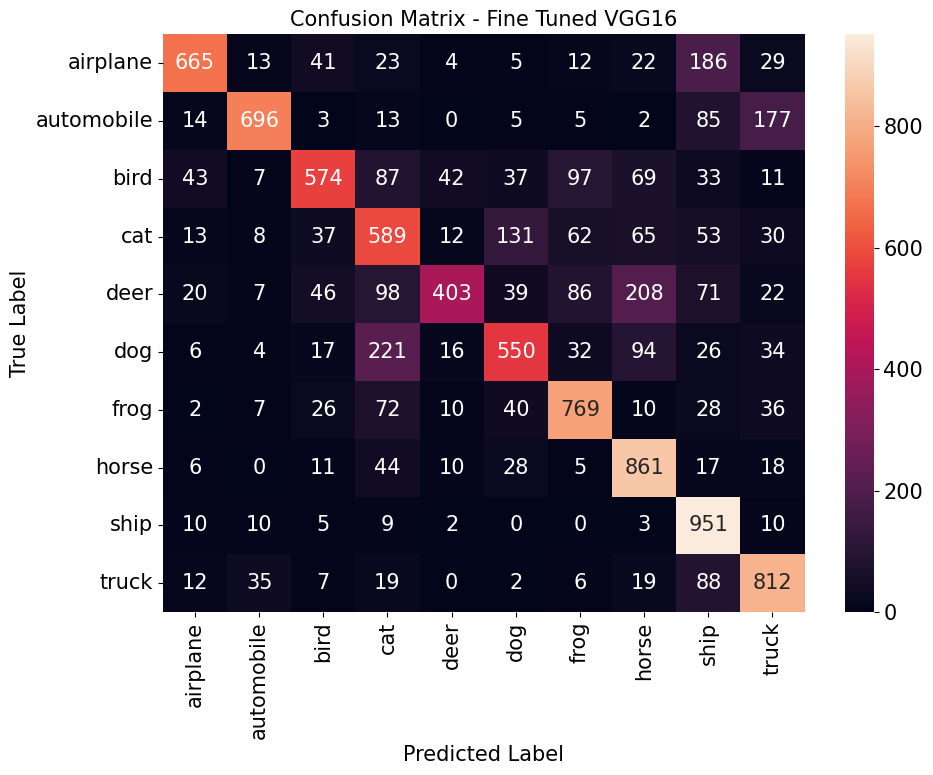

In [53]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine Tuned VGG16")
plt.tight_layout()
plt.savefig("images/confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [54]:
print(classification_report(y_test,y_pred,target_names=classes))

              precision    recall  f1-score   support

    airplane       0.84      0.67      0.74      1000
  automobile       0.88      0.70      0.78      1000
        bird       0.75      0.57      0.65      1000
         cat       0.50      0.59      0.54      1000
        deer       0.81      0.40      0.54      1000
         dog       0.66      0.55      0.60      1000
        frog       0.72      0.77      0.74      1000
       horse       0.64      0.86      0.73      1000
        ship       0.62      0.95      0.75      1000
       truck       0.69      0.81      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.71      0.69      0.68     10000
weighted avg       0.71      0.69      0.68     10000



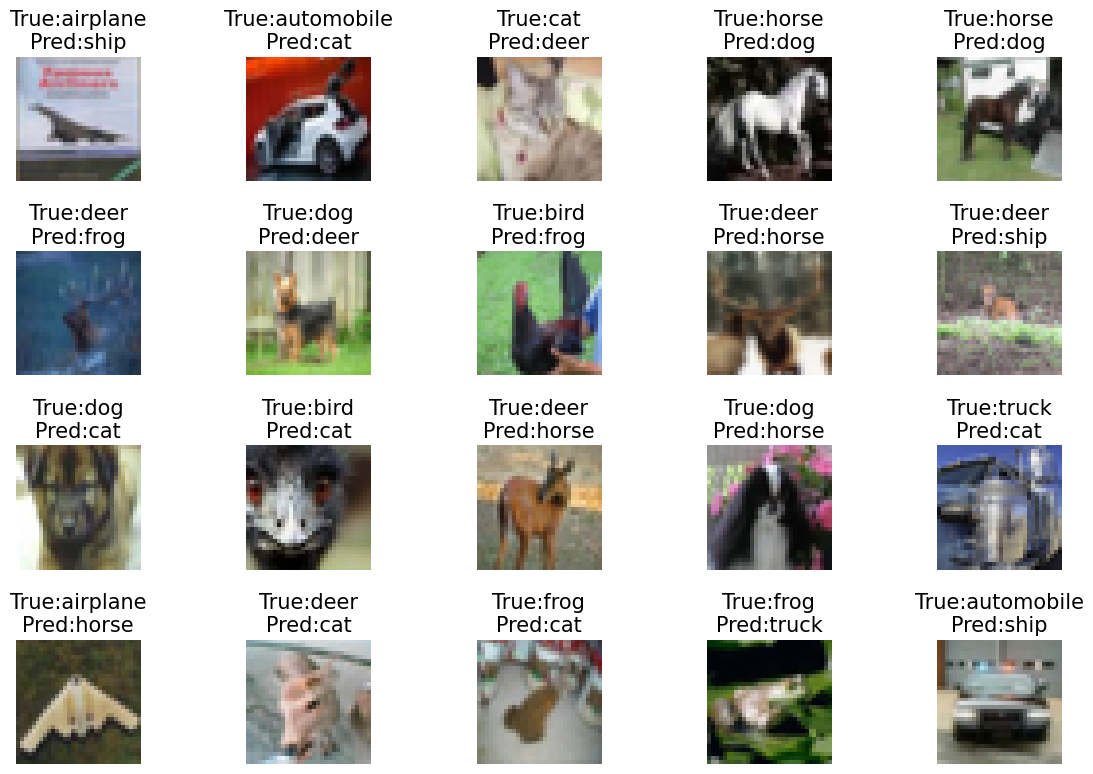

In [55]:
misclassified=np.where(y_test!=y_pred)[0]

plt.figure(figsize=(12,8))

for i,index in enumerate(misclassified[:20]):
 plt.subplot(4,5,i+1)
 plt.imshow(x_test[index])
 plt.title("True:"+classes[y_test[index]]+"\nPred:"+classes[y_pred[index]])
 plt.axis("off")

plt.tight_layout()
plt.savefig("images/misclassified_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [56]:
print("FINAL RESULTS")
print("Training Accuracy:",history.history["accuracy"][-1])
print("Validation Accuracy:",history.history["val_accuracy"][-1])
print("Testing Accuracy:",test_accuracy)
print("Test Loss:",test_loss)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("Initial Training Time:",initial_training_time)
print("Fine Tuning Time:",fine_tuning_time)
print("Total Parameters:",total_parameters)
print("Initial Trainable Parameters:",trainable_parameters)
print("Fine Tuned Trainable Parameters:",fine_trainable_parameters)
print("Fine Tuned Non Trainable Parameters:",fine_non_trainable_parameters)
print("Fine Tuned Validation Accuracy:",fine_history.history["val_accuracy"][-1])

FINAL RESULTS
Training Accuracy: 0.64811110496521
Validation Accuracy: 0.6144000291824341
Testing Accuracy: 0.6869999766349792
Test Loss: 1.2687395811080933
Precision: 0.7098883103648855
Recall: 0.687
F1-score: 0.6817452064560451
Initial Training Time: 73.14656233787537
Fine Tuning Time: 97.25957703590393
Total Parameters: 14848586
Initial Trainable Parameters: 133898
Fine Tuned Trainable Parameters: 7213322
Fine Tuned Non Trainable Parameters: 7635264
Fine Tuned Validation Accuracy: 0.6959999799728394
